# 07 — Naive Bayes

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**
**Notebook 7 of 20**

Naive Bayes is a family of classifiers built directly on Bayes' Theorem, with one deliberately
simplifying ("naive") assumption. It's fast, works well on high-dimensional data like text, and is the
classic algorithm for spam filtering — which this notebook builds from scratch on a small toy dataset.

**Datasets:** `load_breast_cancer` (continuing from Notebooks 5-6, for `GaussianNB` on continuous
features) and a small hand-built spam/ham email corpus (fully offline — no network download) for the
text classification use case with `MultinomialNB` and `BernoulliNB`.


## 1. Conditional Probability and Bayes' Theorem

$P(A \mid B)$ — "the probability of A **given that** B has already happened" — is a **conditional
probability**. It's generally very different from $P(A)$ alone: "probability it rains today" vs.
"probability it rains today *given that* the sky is currently full of dark clouds" are very different
numbers.

**Bayes' Theorem** relates a conditional probability to its *reverse*:

$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}$$

This is powerful because $P(B \mid A)$ is very often **easier to know or estimate** than
$P(A \mid B)$ directly. Classic example: a rare disease test.

- $P(\text{disease}) = 0.01$ (1% of the population has it — the **prior**)
- $P(\text{positive test} \mid \text{disease}) = 0.99$ (the test is 99% sensitive — easy for a lab to
  measure directly, by testing known-positive patients)
- $P(\text{positive test} \mid \text{no disease}) = 0.05$ (5% false-positive rate)

What we actually want to know when someone tests positive is the **reverse**:
$P(\text{disease} \mid \text{positive test})$ — and Bayes' Theorem is exactly the tool that gets us
there from the numbers above.


In [1]:
# Bayes' Theorem worked example: rare disease test
p_disease = 0.01
p_pos_given_disease = 0.99          # sensitivity
p_pos_given_no_disease = 0.05       # false-positive rate

p_no_disease = 1 - p_disease
# P(positive) via the law of total probability: sum over both ways of testing positive
p_positive = (p_pos_given_disease * p_disease) + (p_pos_given_no_disease * p_no_disease)

# Bayes' Theorem: P(disease | positive) = P(positive | disease) * P(disease) / P(positive)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_positive

print(f"P(disease)                        = {p_disease:.3f}   <- the PRIOR, before seeing any test result")
print(f"P(positive test)                  = {p_positive:.4f}")
print(f"P(disease | positive test)        = {p_disease_given_pos:.4f}   <- the POSTERIOR, after seeing the result")
print(f"\nEven with a 99%-sensitive test, only about {p_disease_given_pos:.0%} of people who test positive")
print("actually have the disease -- because the disease is rare, most positives come from the much")
print("larger pool of healthy people hitting the 5% false-positive rate. This is exactly why Bayes'")
print("Theorem matters: intuition badly misjudges this without doing the actual calculation.")


P(disease)                        = 0.010   <- the PRIOR, before seeing any test result
P(positive test)                  = 0.0594
P(disease | positive test)        = 0.1667   <- the POSTERIOR, after seeing the result

Even with a 99%-sensitive test, only about 17% of people who test positive
actually have the disease -- because the disease is rare, most positives come from the much
larger pool of healthy people hitting the 5% false-positive rate. This is exactly why Bayes'
Theorem matters: intuition badly misjudges this without doing the actual calculation.


## 2. From Bayes' Theorem to a Classifier

For classification, relabel the pieces: $A$ becomes a class $C$, $B$ becomes the observed features
$X = (x_1, \dots, x_n)$:

$$P(C \mid X) = \frac{P(X \mid C)\, P(C)}{P(X)}$$

- $P(C)$ — the **prior**: how common each class is overall, before looking at features.
- $P(X \mid C)$ — the **likelihood**: how probable this particular combination of feature values is,
  *given* that the example belongs to class $C$.
- $P(X)$ — same for every class being compared, so it can be dropped when just picking the most likely
  class (it's a normalizing constant).
- $P(C \mid X)$ — the **posterior**: what we actually want — the probability of each class given the
  observed features. Naive Bayes predicts whichever class has the highest posterior.

## 3. The "Naive" Independence Assumption

Estimating $P(X \mid C) = P(x_1, x_2, \dots, x_n \mid C)$ directly is generally intractable — it would
require enough data to estimate the joint probability of every possible *combination* of feature
values for each class, which grows explosively with the number of features.

Naive Bayes makes a simplifying — "naive" — assumption: **every feature is conditionally independent of
every other feature, given the class.** This lets the joint probability factor into a simple product:

$$P(x_1, x_2, \dots, x_n \mid C) \approx P(x_1 \mid C) \cdot P(x_2 \mid C) \cdots P(x_n \mid C)$$

This is why it's called **naive**: features are essentially never *actually* independent given the
class in real data (e.g., for spam email, "contains 'free'" and "contains 'winner'" are correlated with
each other even among spam emails, not just correlated with being spam) — the assumption is known to be
false, yet the classifier still works remarkably well in practice, especially for high-dimensional data
like text, because what matters for classification is getting the *relative ranking* of classes right,
not perfectly calibrated joint probabilities.


## 4. Gaussian Naive Bayes — for continuous features

When features are continuous (like the breast cancer measurements), `GaussianNB` assumes each feature,
within each class, follows a **Normal (Gaussian) distribution** — it estimates a mean and variance per
feature per class from the training data, then uses the Gaussian probability density function to
compute each $P(x_i \mid C)$.


GaussianNB test accuracy: 0.9386
GaussianNB test Log Loss: 0.3713


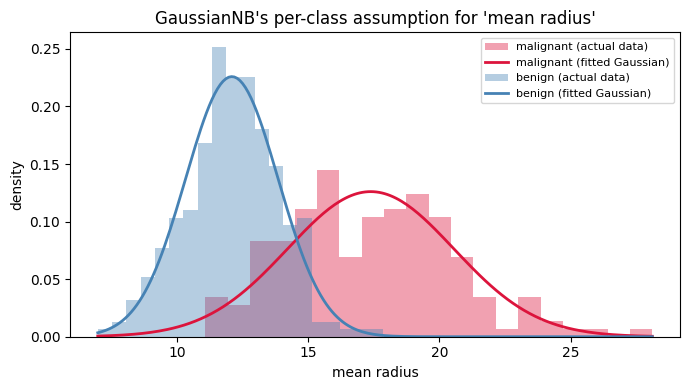

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer(as_frame=True)
Xc, yc = data.data, data.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=42)

gnb = GaussianNB()
gnb.fit(Xc_train, yc_train)
yc_pred = gnb.predict(Xc_test)
yc_proba = gnb.predict_proba(Xc_test)

print(f"GaussianNB test accuracy: {accuracy_score(yc_test, yc_pred):.4f}")
print(f"GaussianNB test Log Loss: {log_loss(yc_test, yc_proba):.4f}")

# Visualize the per-class Gaussian NB actually fits, for one informative feature
feature = "mean radius"
fig, ax = plt.subplots(figsize=(7, 4))
for cls, name, color in [(0, "malignant", "crimson"), (1, "benign", "steelblue")]:
    vals = Xc_train.loc[yc_train == cls, feature]
    ax.hist(vals, bins=20, density=True, alpha=0.4, color=color, label=f"{name} (actual data)")
    mu, sigma = vals.mean(), vals.std()
    xs = np.linspace(Xc_train[feature].min(), Xc_train[feature].max(), 200)
    gaussian_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
    ax.plot(xs, gaussian_pdf, color=color, linewidth=2, label=f"{name} (fitted Gaussian)")
ax.set_xlabel(feature); ax.set_ylabel("density")
ax.set_title(f"GaussianNB's per-class assumption for '{feature}'")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("gaussian_nb.png", dpi=120)
plt.show()


**Reading the plot:** GaussianNB fits one bell curve per class per feature — the two curves
being well-separated (as they are here for `mean radius`) is exactly what makes a feature *useful* for
Naive Bayes: it means observing a particular value of that feature meaningfully shifts which class is
more likely, even before combining it with any other feature.


## 5. Text Classification — Multinomial and Bernoulli Naive Bayes

Naive Bayes is the classic algorithm for **text classification** (spam filtering, sentiment, topic
labeling) because text, once turned into word-count or word-presence vectors, is extremely
high-dimensional (one feature per vocabulary word) and often has genuinely sparse, near-independent-
enough signal per word — exactly the regime where Naive Bayes' assumption hurts the least and its speed
helps the most.

- **`MultinomialNB`**: features are word **counts** (how many times each word appears). Standard choice
  for text classification with a bag-of-words or TF-IDF representation.
- **`BernoulliNB`**: features are word **presence/absence** (binary: did this word appear at all,
  ignoring how many times). Can work better for short texts where a word appearing once vs. many times
  isn't a meaningful distinction.


In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# A small, hand-built spam/ham corpus (fully offline -- no dataset download required).
emails = [
    ("win a free lottery prize now", "spam"),
    ("free cash prize click now to win", "spam"),
    ("congratulations you win a free vacation", "spam"),
    ("claim your free prize winner click here", "spam"),
    ("limited offer free money click now", "spam"),
    ("act now to win free cash prize", "spam"),
    ("you have won a free lottery ticket", "spam"),
    ("urgent click now claim your free reward", "spam"),
    ("can we meet for lunch tomorrow", "ham"),
    ("please review the attached project report", "ham"),
    ("let us schedule the meeting for next week", "ham"),
    ("here are the notes from today's class", "ham"),
    ("can you send me the assignment file", "ham"),
    ("thanks for your help with the project", "ham"),
    ("the meeting has been moved to friday", "ham"),
    ("please find attached the report you asked for", "ham"),
]
texts = [t for t, _ in emails]
labels = [l for _, l in emails]

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(texts)
print("Vocabulary (features):", vectorizer.get_feature_names_out())
print("Shape of word-count matrix:", X_counts.shape, " (n_emails x n_vocabulary_words)")

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_counts, labels, test_size=4, random_state=1, stratify=labels
)

mnb = MultinomialNB().fit(Xt_train, yt_train)
bnb = BernoulliNB().fit(Xt_train, yt_train)

print(f"\nMultinomialNB test accuracy: {accuracy_score(yt_test, mnb.predict(Xt_test)):.2f}")
print(f"BernoulliNB test accuracy:   {accuracy_score(yt_test, bnb.predict(Xt_test)):.2f}")

# Try it on brand-new, unseen messages
new_messages = [
    "free prize click now to win cash",
    "let us meet tomorrow to review the report",
]
new_counts = vectorizer.transform(new_messages)
for msg, pred, proba in zip(new_messages, mnb.predict(new_counts), mnb.predict_proba(new_counts)):
    spam_idx = list(mnb.classes_).index("spam")
    print(f"\n'{msg}'\n  -> predicted: {pred}   (P(spam) = {proba[spam_idx]:.3f})")


Vocabulary (features): ['act' 'are' 'asked' 'assignment' 'attached' 'been' 'can' 'cash' 'claim'
 'class' 'click' 'congratulations' 'file' 'find' 'for' 'free' 'friday'
 'from' 'has' 'have' 'help' 'here' 'let' 'limited' 'lottery' 'lunch' 'me'
 'meet' 'meeting' 'money' 'moved' 'next' 'notes' 'now' 'offer' 'please'
 'prize' 'project' 'report' 'review' 'reward' 'schedule' 'send' 'thanks'
 'the' 'ticket' 'to' 'today' 'tomorrow' 'urgent' 'us' 'vacation' 'we'
 'week' 'win' 'winner' 'with' 'won' 'you' 'your']
Shape of word-count matrix: (16, 60)  (n_emails x n_vocabulary_words)

MultinomialNB test accuracy: 1.00
BernoulliNB test accuracy:   1.00

'free prize click now to win cash'
  -> predicted: spam   (P(spam) = 1.000)

'let us meet tomorrow to review the report'
  -> predicted: ham   (P(spam) = 0.002)


## 6. Interpreting the result

Notice `MultinomialNB` learned to flag "free", "click", "now", "prize", "win" as spam-associated purely
from 12 tiny training examples — this is Naive Bayes' core strength: because it estimates one
probability *per word independently* rather than trying to model word combinations jointly, it needs
comparatively little data per feature to get useful estimates, unlike models that must learn
interactions between features.

This toy example is small enough to sanity-check by eye, but the exact same mechanism (word counts →
per-class word probabilities → combine via the naive independence assumption) is what powered real
production spam filters for years, and still forms a fast, strong baseline for text classification
today — worth comparing against before reaching for something heavier.


## 7. Summary — Key Takeaways

- Bayes' Theorem lets you compute $P(C \mid X)$ (what you want) from $P(X \mid C)$ and $P(C)$ (what's
  often easier to estimate from data) — the disease-test example shows how badly intuition can misjudge
  this without the actual calculation.
- Naive Bayes assumes every feature is conditionally independent given the class — an assumption that's
  essentially always technically false, but that keeps the model fast, simple, and surprisingly
  effective, especially in high dimensions like text.
- `GaussianNB` fits continuous features; `MultinomialNB` fits word/event counts; `BernoulliNB` fits
  binary presence/absence — pick the variant that matches your feature type.
- Text classification (spam filtering, topic labeling) is Naive Bayes' classic use case, because
  bag-of-words features are high-dimensional and roughly independent-enough for the assumption to do
  little damage.


## 8. Try It Yourself (no solutions given)

1. Add 4-6 more of your own example emails (spam and ham) to the `emails` list in Section 5, re-run the
   cell, and test a brand-new message related to your additions. Does the model correctly classify it?
2. Compute `mnb.predict_proba` for a genuinely ambiguous message you write yourself (something with a
   mix of spam-like and ham-like words). Is the model confident (probability near 0 or 1) or uncertain
   (probability near 0.5)? What does that tell you about how "in-vocabulary" your ambiguous words are?
3. Refit `GaussianNB` on the breast cancer data using only the 3 features whose per-class Gaussian
   curves (plot them the way Section 4 did) look the *most* overlapping/least separated. Does accuracy
   drop compared to using all 30 features? Connect this back to what "informative feature" meant in
   Section 4.
4. In your own words: why does Naive Bayes tend to do relatively well on text classification despite an
   independence assumption that's obviously false for real language (e.g., "New" and "York" are far
   from independent)? What does that imply about when the naive assumption hurts a lot versus a little?
